In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Load Data
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
#2. Cleaning Data: Remove the leading '[' and the ending ')' from age and repalce '?' from weight to NAN
df['age'] = df['age'].str.strip('[').str.strip(')')
df['weight'] = df['weight'].replace('?', 'NaN')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,0-10,NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,10-20,NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,20-30,NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,30-40,NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,40-50,NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# 3. Group: (Male vs Female) and diabetesMed Feature (time_in_hospital)
df.groupby(['gender', 'diabetesMed'])['time_in_hospital'].mean()


gender           diabetesMed
Female           No             4.166396
                 Yes            4.575394
Male             No             3.916802
                 Yes            4.409526
Unknown/Invalid  No             1.000000
                 Yes            4.500000
Name: time_in_hospital, dtype: float64

In [ ]:
# 4. Descriptive Statistics: readmitted summary of time_in_hospital and average stay by gender
print(df.groupby(['gender'])['time_in_hospital'].describe())
print(df.groupby(['gender'])['time_in_hospital'].mean())


                   count      mean       std  min  25%  50%  75%   max
gender                                                                
Female           54708.0  4.478797  2.980388  1.0  2.0  4.0  6.0  14.0
Male             47055.0  4.299777  2.987703  1.0  2.0  3.0  6.0  14.0
Unknown/Invalid      3.0  3.333333  4.041452  1.0  1.0  1.0  4.5   8.0
gender
Female             4.478797
Male               4.299777
Unknown/Invalid    3.333333
Name: time_in_hospital, dtype: float64


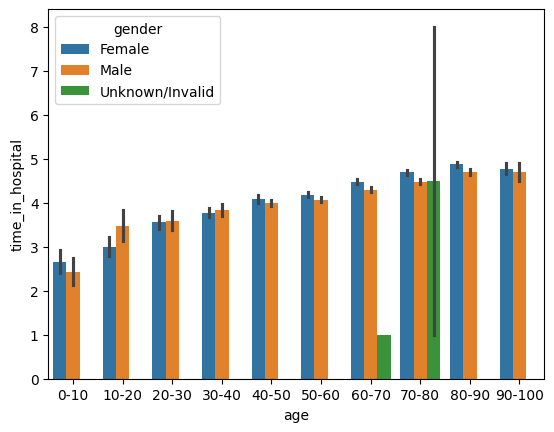

In [ ]:
# 5. Visualization: Average time_in_hospital by age group and gender
sns.barplot(x='age', y='time_in_hospital', hue='gender', data=df)
plt.show()

CONCLUSION

The data indentifies that female patients tend to stay in the hospital slightly longer than the male patients.